In [1]:
# --- Celda 1.1: Importaciones y Carga de Librerías Offline ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import ROOT
import time
import traceback
from multiprocessing import Pool, cpu_count # <-- Importamos Pool
from functools import partial

Welcome to JupyROOT 6.30/04


In [2]:
# Esta es la parte MÁS IMPORTANTE:
# Asegúrate de que estás corriendo este Jupyter Lab desde una terminal
# donde ANTES hiciste: source /ruta/a/auger/offline/this-auger-offline.sh

AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError(
        "AUGEROFFLINEROOT no definido. "
        "Reinicia Jupyter Lab desde una terminal donde hayas "
        "hecho: "
        " 'aug_set_version offline 4.0.1-icrc23-prod1-root6' "   
        " 'source /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6/bin/this-auger-offline.sh'."
    )

print(f"AUGEROFFLINEROOT encontrado en: {AugerOfflineRoot}")

# Cargar las librerías necesarias
print("Cargando librerías de Auger Offline...")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    lib_path = os.path.join(AugerOfflineRoot, "lib", lib)
    if not os.path.exists(lib_path):
        raise FileNotFoundError(f"No se encontró la librería: {lib_path}")
    
    # Usamos gSystem.Load que es más robusto en PyROOT
    status = ROOT.gSystem.Load(lib_path)
    if status < 0:
        raise ImportError(f"Error cargando la librería: {lib_path}")

print("Librerías cargadas correctamente. ¡Listo para trabajar! 🚀")

AUGEROFFLINEROOT encontrado en: /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6
Cargando librerías de Auger Offline...
Librerías cargadas correctamente. ¡Listo para trabajar! 🚀


In [9]:
# --- Celda 2.1: Funciones Auxiliares y Principales (¡LÓGICA DE PHI CORREGIDA!) ---

# --- getModuleList sigue igual ---
def getModuleList(counter, sim=True):
    possibleModules = range(0, 6) if sim else range(100, 116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

def readADST_surface_v7(fname, is_mc_simulation=True):
    """
    Leer un archivo ADST (1 fila por MÓDULO).
    Itera sobre MDEvent.
    Guarda un flag 'is_sd_saturated'.
    ❗️ CORRIGE el cálculo de 'phi_plane' para el anillo denso (90k).
    """
    
    print(f"Iniciando lectura de: {os.path.basename(fname)}")
    
    if not os.path.exists(fname):
        print(f"Advertencia: Archivo no encontrado {fname}")
        return pd.DataFrame() # Retorna DF vacío

    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = [] 
    event_count = 0
    start_time = time.time()

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        if event_count % 500 == 0:
            print(f"... procesados {event_count} eventos.")

        event_id_lluvia = event.GetEventId()
        
        MCShower = event.GetGenShower()
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        primary = MCShower.GetShortPrimaryName()
        
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        theta_REC = sShower.GetZenith() * 180.0 / np.pi
        phi_REC = sShower.GetAzimuth() * 180.0 / np.pi
        
        
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__()
            counterId = counter.GetId()
            sdId = counter.GetSdPartnerId()

            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            if sdStation is None:
                counterIterator += 1
                continue 

            is_sd_saturated = sdStation.IsLowGainSaturated()
            r = sdStation.GetSPDistance()
            r_core = r
            r_core_err = sdStation.GetSPDistanceError()
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal()
            
            # --- ❗️❗️❗️ INICIO DE LA CORRECCIÓN DE PHI ❗️❗️❗️ ---
            
            shower_azimuth_rec = sShower.GetAzimuth() # Guardamos el azimut de la lluvia REC
        
            station_azimuth_sp = sdStation.GetAzimuthSP() # Ángulo de la estación en plano de lluvia
            
            if sdId >= 90000 and sdId < 100000:
                # Es un counter del Anillo Denso (90k)
                # El ángulo YA está referido al eje de la lluvia (MC).
                # No necesitamos restar el azimut de la lluvia REC.
                phi_rel = station_azimuth_sp
            else:
                # Es un counter del Infill normal (4xxx)
                # El ángulo está referido al Norte, debemos restar el azimut de la lluvia.
                phi_rel = station_azimuth_sp - shower_azimuth_rec

            # Calculamos x, y, phi (común para ambos)
            x_plane = r * np.cos(phi_rel)
            y_plane = r * np.sin(phi_rel)
            phi_plane = np.arctan2(y_plane, x_plane) % (2 * np.pi) # Rango [0, 2*pi]
            
            # --- ❗️❗️❗️ FIN DE LA CORRECCIÓN DE PHI ❗️❗️❗️ ---
            
            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:
                
                nMuones = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()

                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"

                data.append({
                    "event_id": event_id_lluvia,
                    
                    # Info MC
                    "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
                    
                    # Info REC
                    "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
                    
                    # Info Módulo/Counter
                    "counterId": counter.GetId(),
                    "moduleId": moduleId,
                    "nMuones": nMuones,
                    "module_status": status,      # <-- ¡NUEVO!
                    "is_sd_saturated": is_sd_saturated, # <-- ¡NUEVA COLUMNA!
                    
                    # Info de Geometría (plano de lluvia)
                    "x_plane": x_plane,
                    "y_plane": y_plane,
                    "phi_plane": phi_plane, # <-- ¡Ahora está bien calculado!
                    "r_core": r_core,
                    "r_core_err": r_core_err,      # <-- ¡NUEVO!
                    
                    # Info de Señal (SD)
                    "sdId": sdId,
                    "sdSignal": sdSignal,
                    "sdSignal_err": sdSignal_err,  # <-- ¡NUEVO!
                    "sdMuonSignal": sdMuonSignal   # <-- ¡NUEVO!
                })
            
            counterIterator += 1
        
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"Lectura completa. Total de eventos leídos: {event_count}")
    print(f"Tiempo total de lectura: {elapsed:.2f} segundos.")
    print(f"Total de 'MÓDULOS' (filas) extraídos: {len(data)}")

    df = pd.DataFrame(data)
    return df

In [10]:
# -----------------------------------------------------------------
# FUNCIÓN "TRABAJADORA"
# ❗️ 2. AHORA ACEPTA 'output_dir' COMO ARGUMENTO
# -----------------------------------------------------------------
def process_file_wrapper(root_fpath, output_dir):
    
    # 1. Definir rutas
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    # 2. Evitar reprocesar
    if os.path.exists(output_path):
        return f"INFO: El archivo ya existe, saltando: {output_filename}"

    # 3. Imprimir estado
    print(f"► [Iniciando]: {filename}")
    
    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (¡Llama a la función de la Celda 2.1!)
        # (Asegurate de que tu Celda 2.1 se llame 'readADST_surface' 
        # o cambiá el nombre aquí abajo)
        df = readADST_surface_v7(root_fpath) 
        
        if df.empty:
            return f"INFO: Archivo vacío o sin datos UMD. Saltando: {filename}"

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata en {filename}: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        elapsed = end_file_time - start_file_time
        return f"✔ [Éxito]: {filename} -> {output_filename} ({elapsed:.2f}s)"

        # ----- FIN DEL TRABAJO -----

    except Exception as e:
        # Si algo falla, retornamos el string de error
        return f"❌ [ERROR] en {filename}: {e}\n{traceback.format_exc()}"

# Prueba

In [11]:
print("--- INICIANDO PROCESO SERIAL (MODO DE PRUEBA: 1 ARCHIVO) ---")
start_total_time = time.time()

# --- 1. Configuración de Rutas ---
base_path = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium"
output_dir = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/"

os.makedirs(output_dir, exist_ok=True)
print(f"Buscando archivos en: {base_path}")
print(f"Los archivos .parquet se guardarán en: {output_dir}")

# --- 2. Encontrar todos los archivos ---
all_root_files = glob.glob(os.path.join(base_path, "*.root"))
all_root_files.sort()

if not all_root_files:
    print(f"¡Error! No se encontraron archivos .root en: {base_path}")
else:
    print(f"Encontrados {len(all_root_files)} archivos .root para procesar.")

# --- 3. Bucle de Procesamiento Serial ---
exitos = 0
errores = 0

for i, root_fpath in enumerate(all_root_files):
    
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    print(f"\n--- Procesando archivo {i+1}/{len(all_root_files)} ---")
    print(f"► {filename}")
    
    # Evita reprocesar archivos que ya existen
    if os.path.exists(output_path):
        print(f"INFO: El archivo ya existe, saltando: {output_filename}")
        continue

    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (usa la Celda 2.1)
        df = readADST_surface_v7(root_fpath)
        
        if df.empty:
            print(f"INFO: Archivo vacío o sin datos UMD. Saltando.")
            continue

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        print(f"✔ [Éxito]: Guardado como {output_filename}")
        print(f"Tiempo de este archivo: {end_file_time - start_file_time:.2f}s")
        exitos += 1
        
        # ----- FIN DEL TRABAJO -----
        
        # ❗️ LÍNEA DE PRUEBA AÑADIDA ❗️
        print("\n--- ¡PRUEBA DETENIDA! Saliendo del bucle después de 1 archivo. ---")
        break  # Esto detiene el 'for' después de la primera pasada exitosa
               # ELIMINÁ ESTA LÍNEA para procesar todos los archivos.

    except Exception as e:
        print(f"❌ [ERROR] en {filename}: {e}")
        print(traceback.format_exc())
        errores += 1

# --- 4. Resumen Final ---
end_total_time = time.time()
print("\n\n--- Proceso Completado ---")
print(f"Tiempo total: {(end_total_time - start_total_time) / 60:.2f} minutos")
print(f"Total de archivos procesados: {exitos + errores}")
print(f"Éxitos: {exitos}")
print(f"Errores: {errores}")
print(f"¡Listo! Tu archivo .parquet de prueba está en: {output_dir}")

--- INICIANDO PROCESO SERIAL (MODO DE PRUEBA: 1 ARCHIVO) ---
Buscando archivos en: /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium
Los archivos .parquet se guardarán en: /home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/
Encontrados 20 archivos .root para procesar.

--- Procesando archivo 1/20 ---
► SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
INFO: El archivo ya existe, saltando: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet

--- Procesando archivo 2/20 ---
► SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.root
Iniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.root
... procesados 500 eventos.
... procesados 1000 eventos.
Lectura completa. Total de eventos leídos: 1223
Tiempo total de lectura: 394.54 segundos.
Total de 'MÓDULOS' (filas) extraídos: 81918
✔ [Éxito]: Guardado como SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.parquet
Tiempo

  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.root
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Detector read from file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.root
   has the same version (=27) as the active class but a different checksum.
   You should update the version to ClassDef(Detector,28).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the on-file layout version 27 of class 'Detector' differs from 
the in-memory layout version 27:
   map<int,EyePointingIdMap> fTelPointingIds; //
vs
   map<int,map<int,TString> > fTelPointingIds; //
Warning in <TStreamerInfo::BuildCheck>: 
   The 

In [18]:
# --- Cargar tu nuevo DataFrame (1 fila por MÓDULO) ---
parquet_path = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.parquet"
df_new = pd.read_parquet(parquet_path)

print(f"DataFrame 'df_new' cargado con {len(df_new)} filas (MÓDULOS).")

# --- 1. Inspeccionar las nuevas columnas ---
print("\n--- Head (con nuevas columnas) ---")

print(df_new.head(10)) # Muestro 10 filas para ver el cambio de módulo

# --- 2. ¡La verificación CLAVE! ---
# Ver qué estados de módulo capturaste
print("\n--- Conteo de 'module_status' ---")
print(df_new['module_status'].value_counts())

DataFrame 'df_new' cargado con 81918 filas (MÓDULOS).

--- Head (con nuevas columnas) ---
                                            event_id    logE_MC   theta_MC  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
5  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
6  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
7  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
8  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
9  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   

       phi_MC primary   logE_REC  theta_REC     phi

In [19]:
print(df_new['counterId'].unique())

[ 90000  90001  90002  90003  90004  90005  90006  90007  90008  90009
  90010  90011 104004 104012 104013 104014 104027 104028 104029 104047
 104048 104049 104031 104032 104052 104053 104054 104055 104212 104213
 104214 104017 104018 104033 104034 104035 104056 104057 104059 104016
 104216 104001 104002 104003 104007 104009 104010 104011 104022 104023
 104024 104041 104043 104005 104006 104015 104030 104019 104036 104037
 104060 104061 104025 104026 104044 104045 104008 104020 104021 104075
 104215 104218 104042 104046 104217 104039 104040 104063 104073 104074
 104058 104067 104093 104050 104072 104038 104051 104112 104102 104076
 104062 104140 104106 104096 104080 104095 104162 104068 104118 104064
 104114 104082 104097 104115 104196 104098 104085 104086 104090 104069
 104167 104107 104070 104077 104078 104094 104083 104127 104147 104109
 104101 104121 104089 104155 104125 104198 104113]


--- Testeando Counter 90000 (Anillo Denso) ---
count    3621.000000
mean        3.090037
std         3.090225
min         0.000000
25%         0.035559
50%         0.251225
75%         6.249506
max         6.283071
Name: phi_plane, dtype: float64


--- Testeando Counter 104022 (Infill Normal) ---
count    558.000000
mean       2.907836
std        1.754142
min        0.000000
25%        1.329697
50%        2.811101
75%        4.447664
max        6.185052
Name: phi_plane, dtype: float64


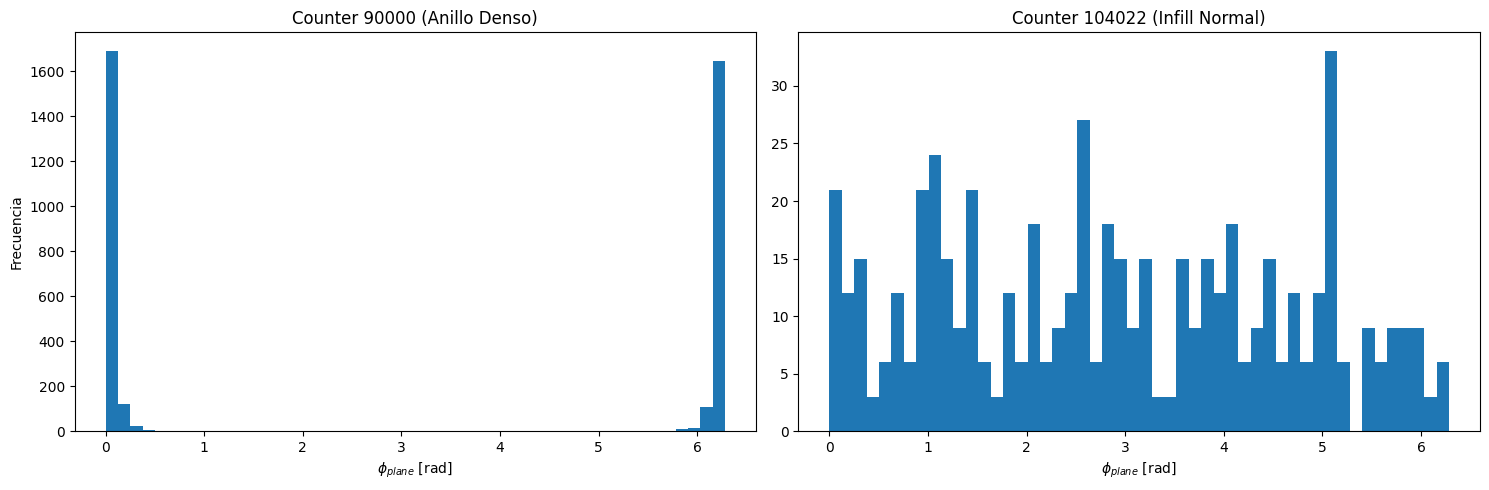

In [20]:
# --- 1. TEST NUMÉRICO ---

print("--- Testeando Counter 90000 (Anillo Denso) ---")
# Filtramos para ver solo los módulos del counter 90000
df_90000 = df_new[df_new['counterId'] == 90000]

if not df_90000.empty:
    # Usamos .describe() en la columna 'phi_plane'
    # Esta columna está en radianes [0, 2*pi]
    print(df_90000['phi_plane'].describe())
else:
    print("No se encontraron datos para el Counter 90000 en este archivo.")

print("\n" + "="*30 + "\n")

print("--- Testeando Counter 104022 (Infill Normal) ---")
# Filtramos para ver solo los módulos del counter 104022
# (Uso 104022 porque apareció en tu output anterior, podés usar cualquier 104xxx)
df_104022 = df_new[df_new['counterId'] == 104022]

if not df_104022.empty:
    # Usamos .describe()
    print(df_104022['phi_plane'].describe())
else:
    print("No se encontraron datos para el Counter 104022 en este archivo.")

# --- 2. TEST VISUAL (Histogramas) ---
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para el 90000
if not df_90000.empty:
    axs[0].hist(df_90000['phi_plane'], bins=50, range=(0, 2*np.pi))
    axs[0].set_title("Counter 90000 (Anillo Denso)")
    axs[0].set_xlabel(r"$\phi_{plane}$ [rad]")
    axs[0].set_ylabel("Frecuencia")
else:
    axs[0].set_title("Counter 90000 (Sin datos)")

# Histograma para el 104022
if not df_104022.empty:
    axs[1].hist(df_104022['phi_plane'], bins=50, range=(0, 2*np.pi))
    axs[1].set_title("Counter 104022 (Infill Normal)")
    axs[1].set_xlabel(r"$\phi_{plane}$ [rad]")
else:
    axs[1].set_title("Counter 104022 (Sin datos)")

plt.tight_layout()
plt.show()